# easypandas — Simple Data Exploration for Students

`easypandas` is a small educational wrapper around **pandas** that provides a simpler interface for beginners learning data analysis.

The goal is to allow students to explore datasets using simple and intuitive commands.

Internally it uses the power of **pandas**, but exposes a friendlier syntax.

---

# Creating a Dataset

Example dataset:

## Intro to Dataframes

In [1]:
import pandas as pd
import numpy as np
from easypandas import *

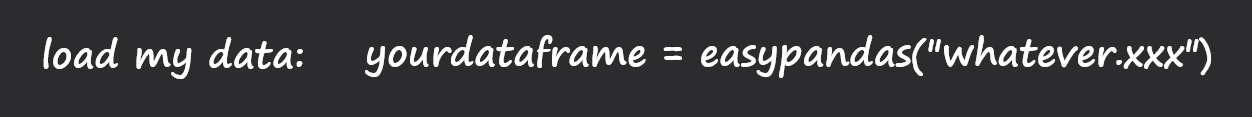

### with pandas

In [2]:
df = pd.DataFrame([[1,2,3,4],[4,5,6,3],[7,8,9,5],[10,11,12,6]], columns=["A", "B", "C","D"])

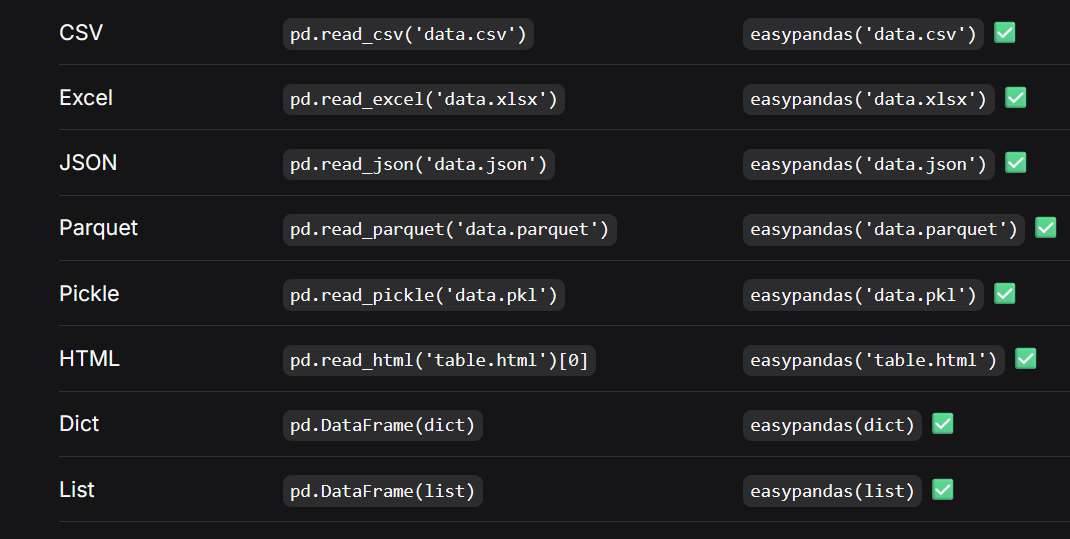

### with easypandas

In [3]:
P = easypandas(df) # atb

In [4]:
df.head()

,A,B,C,D
0,1,2,3,4
1,4,5,6,3
2,7,8,9,5
3,10,11,12,6


In [5]:
P.head()  # atb

,A,B,C,D
0,1,2,3,4
1,4,5,6,3
2,7,8,9,5
3,10,11,12,6


In [6]:
df.tail(2)

,A,B,C,D
2,7,8,9,5
3,10,11,12,6


In [7]:
P(2,3) # easypandas

,A,B,C,D
2,7,8,9,5
3,10,11,12,6


In [8]:
P.end() # Display  last  rows 

,A,B,C,D
0,1,2,3,4
1,4,5,6,3
2,7,8,9,5
3,10,11,12,6


In [9]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='str')

In [10]:
P.columns() # easypandas

['A', 'B', 'C', 'D']

In [11]:
df.index.tolist()

[0, 1, 2, 3]

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A       4 non-null      int64
 1   B       4 non-null      int64
 2   C       4 non-null      int64
 3   D       4 non-null      int64
dtypes: int64(4)
memory usage: 260.0 bytes


In [13]:
df.describe()

,A,B,C,D
count,4.000000,4.000000,4.000000,4.000000
mean,5.500000,6.500000,7.500000,4.500000
std,3.872983,3.872983,3.872983,1.290994
min,1.000000,2.000000,3.000000,3.000000
25%,3.250000,4.250000,5.250000,3.750000
50%,5.500000,6.500000,7.500000,4.500000
75%,7.750000,8.750000,9.750000,5.250000
max,10.000000,11.000000,12.000000,6.000000


In [14]:
df.nunique()

A    4
B    4
C    4
D    4
dtype: int64

In [15]:
df['A'].unique()

array([ 1,  4,  7, 10])

In [16]:
df.shape

(4, 4)

In [17]:
df.size

16

In [18]:
df

,A,B,C,D
0,1,2,3,4
1,4,5,6,3
2,7,8,9,5
3,10,11,12,6


 

### Easypandas: The Universal Selector (`__call__` method)

One of the most powerful features of **Easypandas** is the ability to access data by calling the object `P` directly. This replaces the verbose and sometimes confusing `.iloc`, `.loc`, and `.at` methods from standard Pandas.

#### Syntax Comparison Table

| Action | Standard Pandas | Easypandas (The `P` Way) |
| :--- | :--- | :--- |
| **Get full data** | `df` | `P()` |
| **Get a single row** | `df.iloc[[3]]` | `P(3)` |
| **Row 3, all columns** | `df.iloc[3, :]` | `P(3, ":")` |
| **Range of rows (0 to 3)** | `df.iloc[0:4]` | `P(0, 3)` |
| **Rows 0-3, specific column** | `df.loc[0:3, "Age"]` | `P(0, 3, "Age")` |
| **Rows 0-3, multiple columns**| `df.loc[0:3, ["Name", "Sex"]]` | `P(0, 3, "Name", "Sex")` |
| **Select by Index Label** | `df.loc["ID_105"]` | `P("ID_105")` |
| **Column Range** | `df.loc[:, "Name":"Fare"]` | `P("Name:Fare")` |
| **Label Range (e.g. Days)** | `df.loc["Mon":"Wed"]` | `P("Monday", "Wednesday")` |

---

### Practical Examples for Documentation

#### 1. Quick Data Extraction
In standard Pandas, fetching a range of rows with specific columns requires nested brackets or `.loc`. With **Easypandas**, it's just a function call:

```python
# Standard Pandas
subset = df.loc[10:15, ['Age', 'Survived']]

# Easypandas
subset = P(10, 15, 'Age', 'Survived')
```

#### 2. The "Colon" Shortcut
Easypandas understands the `":"` string as "everything", making it very intuitive to get an entire row's data:

```python
# Get the 5th row as a Series/Object
row_data = P(5, ":")
```

#### 3. Smart Column Slicing
Instead of list indexing, you can use a single string with a colon to define a range of columns:

```python
# Get all columns from 'First Name' to 'Salary'
financial_info = P("First Name:Salary")
```

#### 4. Semantic Time/Label Ranges
If your index uses strings (like days or categories), **Easypandas** handles the range naturally:

```python
# Standard Pandas
weekly_report = df.loc["Monday":"Friday"]

# Easypandas
weekly_report = P("Monday", "Friday")
```

---

### Why use Easypandas over Pandas? (For the README)

* **Readability:** The code looks like a mathematical function `P(x, y)`, making it cleaner and easier to follow.
* **Zero Boilerplate:** No more repeating the dataframe name inside the filter (e.g., `df[df['col'] == val]`).
* **Context-Aware:** `P` automatically knows whether you are asking for an index position (integer) or a label (string).
* **Speed of Development:** You type fewer characters to achieve the same (or better) results.

¿Qué te parece esta estructura? Si quieres, puedo redactar el **README.md** completo en inglés para que solo tengas que copiarlo y pegarlo en tu repo.

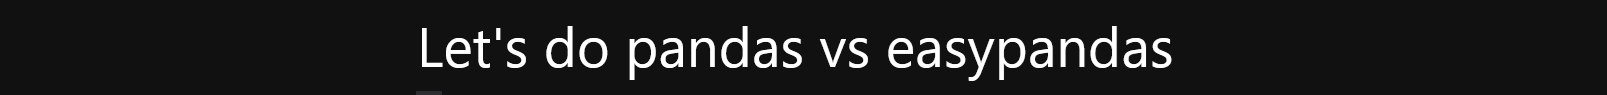

In [19]:
import pandas as pd
from easypandas import *
%pprint

Pretty printing has been turned OFF


#### Loading in Dataframes from Files

In [20]:
df = pd.read_csv('train.csv') 
P = easypandas(df)

#### inside dataframe?

In [21]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [22]:
P.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#### The column names give me a headache

In [23]:
P.columns()

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

In [24]:
P.rename('Row ID',"Id")
P.rename('Order ID',"norden")
P.rename('Order Date',"date")
P.rename('Ship Date',"shipdate")
P.rename('Customer Name',"Name")
P.rename('Customer ID',"IDname")
P.rename('Product ID',"PID")
P.rename('Sub-Category',"subcat")
P.rename('Postal Code',"npostal")
P.rename('Product Name',"descrip")
P.rename('Sub-Category',"SubProd")

In [25]:
P.columns()

['Id', 'norden', 'date', 'shipdate', 'Ship Mode', 'IDname', 'Name', 'Segment', 'Country', 'City', 'State', 'npostal', 'Region', 'PID', 'Category', 'subcat', 'descrip', 'Sales']

#### describe Vs summary

In [26]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [27]:
P.summary()

                                          🔍 easypandas DATA HEALTH CHECK                                          
 FEATURE    TYPE         QTY CAT  SAMPLE DATA                                                           OK    NaNs 
 ID         AUTONUMERIC           1...9800                                                              9800  0    
 NORDEN     STRING                ['CA-2017-152156', 'CA-2017-152156']                                  9800  0    
 DATE       STRING                ['08/11/2017', '08/11/2017']                                          9800  0    
 SHIPDATE   STRING                ['11/11/2017', '11/11/2017']                                          9800  0    
 SHIP MODE  CATEGORIES   4        ['Second Class', 'Standard Class', 'First Class', 'Same Day']         9800  0    
 IDNAME     CATEGORIES   793      ['CG-12520', 'DV-13045', 'SO-20335', 'BH-11710']                      9800  0    
 NAME       CATEGORIES   793      ['Claire Gute', 'Darrin Van Huff', "Sean O'Donnell", 'Brosina         9800  0    
                                  Hoffman']                                                                        
 SEGMENT    CATEGORIES   3        ['Consumer', 'Corporate', 'Home Office']                              9800  0    
 COUNTRY    CATEGORIES   1        ['United States']                                                     9800  0    
 CITY       CATEGORIES   529      ['Henderson', 'Los Angeles', 'Fort Lauderdale', 'Concord']            9800  0    
 STATE      CATEGORIES   49       ['Kentucky', 'California', 'Florida', 'North Carolina']               9800  0    
 NPOSTAL    FLOAT                 [42420.0, 42420.0]                                                    9789  11   
 REGION     CATEGORIES   4        ['South', 'West', 'Central', 'East']                                  9800  0    
 PID        STRING                ['FUR-BO-10001798', 'FUR-CH-10000454']                                9800  0    
 CATEGORY   CATEGORIES   3        ['Furniture', 'Office Supplies', 'Technology']                        9800  0    
 SUBCAT     CATEGORIES   17       ['Bookcases', 'Chairs', 'Labels', 'Tables']                           9800  0    
 DESCRIP    STRING                ['Bush Somerset Collection Bookcase', 'Hon Deluxe Fabric Upholstered  9800  0    
                                  Stacking Chairs, Rounded Back']                                                  
 SALES      FLOAT                 [261.96, 731.94]                                                      9800  0    

 

<div align="center">
    <h1>🐼 Pandas vs. easypandas 🚀</h1>
    <p><i>The intuitive way to access and manipulate DataFrames</i></p>
</div>

### 1. Single Element & Row Access
In standard Pandas, you must constantly switch between `.iloc`, `.loc`, and `.at`. With **easypandas**, the `P` object intelligently understands your intent based on whether you provide an index (integer) or a label (string).

| Goal | Standard Pandas | **easypandas** |
| :--- | :--- | :--- |
| **Get an entire row** | `df.iloc[10]` | `P(10)` |
| **Get cell by position** | `df.iloc[10, 17]` | `P(10, 17)` |
| **Get cell by name** | `df.at[10, 'Sales']` | `P(10, 'Sales')` |

In [28]:
df.iloc[10]

Row ID                                                 11
Order ID                                   CA-2015-115812
Order Date                                     09/06/2015
Ship Date                                      14/06/2015
Ship Mode                                  Standard Class
Customer ID                                      BH-11710
Customer Name                             Brosina Hoffman
Segment                                          Consumer
Country                                     United States
City                                          Los Angeles
State                                          California
Postal Code                                       90032.0
Region                                               West
Product ID                                FUR-TA-10001539
Category                                        Furniture
Sub-Category                                       Tables
Product Name     Chromcraft Rectangular Conference Tables
Sales         

In [29]:
P(10)

,Id,norden,date,shipdate,Ship Mode,IDname,Name,Segment,Country,City,State,npostal,Region,PID,Category,subcat,descrip,Sales
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184


In [30]:
P.values(10)

[11, 'CA-2015-115812', '09/06/2015', '14/06/2015', 'Standard Class', 'BH-11710', 'Brosina Hoffman', 'Consumer', 'United States', 'Los Angeles', 'California', 90032, 'West', 'FUR-TA-10001539', 'Furniture', 'Tables', 'Chromcraft Rectangular Conference Tables', 1706.184]

In [31]:
df.iloc[10, 17]

np.float64(1706.184)

In [32]:
P(10, 17)

,Id,norden,date,shipdate,Ship Mode,IDname,Name,Segment,Country,City,State,npostal,Region,PID,Category,subcat,descrip,Sales
10,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.184
17,18,CA-2015-167164,13/05/2015,15/05/2015,Second Class,AG-10270,Alejandro Grove,Consumer,United States,West Jordan,Utah,84084.0,West,OFF-ST-10000107,Office Supplies,Storage,Fellowes Super Stor/Drawer,55.500


In [33]:
P.values(10, 17)

[[11, 'CA-2015-115812', '09/06/2015', '14/06/2015', 'Standard Class', 'BH-11710', 'Brosina Hoffman', 'Consumer', 'United States', 'Los Angeles', 'California', 90032, 'West', 'FUR-TA-10001539', 'Furniture', 'Tables', 'Chromcraft Rectangular Conference Tables', 1706.184], [18, 'CA-2015-167164', '13/05/2015', '15/05/2015', 'Second Class', 'AG-10270', 'Alejandro Grove', 'Consumer', 'United States', 'West Jordan', 'Utah', 84084, 'West', 'OFF-ST-10000107', 'Office Supplies', 'Storage', 'Fellowes Super Stor/Drawer', 55.5]]

### 2. Powerful Slicing (The "Call" Magic)
Stop using double brackets and complex slicing syntax. **easypandas** simplifies multi-selection into a single function call.

#### **A. Row Ranges (Slicing)**
*   **Standard Pandas:** `df.iloc[0:5]`
*   **easypandas:** `P(0, 5)`

#### **B. Rectangular Blocks (Rows & Columns)**
*   **Standard Pandas:** `df.iloc[0:5, 0:3]`
*   **easypandas:** `P(0, 5, 0, 3)` 

#### **C. Mixing Indices and Labels**
If you want specific rows but filtered by column names:
*   **Standard Pandas:** `df.loc[10:15, ['Name', 'Sales']]`
*   **easypandas:** `P(10, 15, 'Name', 'Sales')`

### 3. Smart Column Selection
You no longer need to pass a list within brackets to select multiple non-adjacent columns.

*   **Standard Pandas:** `df[['Id', 'City', 'Sales']]`
*   **easypandas:** `P('Id', 'City', 'Sales')`

---

### Practical Example with Superstore Data
Using the data from your images (like **image_22b7b6.png** and **image_22b4ed.png**), let's see how much cleaner your code becomes:

```python
# 1. Quick diagnostic
P.summary() 

# 2. Extract specific customer data from the 3rd row (index 2)
# Using standard labels renamed in your setup
customer, amount = P(2, 'Name', 'Sales')
print(f"Customer: {customer} | Spent: ${amount}")
# Output: Customer: Darrin Van Huff | Spent: $14.62

# 3. Get a slice of the first 5 rows for specific columns
# No complex .iloc or .loc needed
preview = P(0, 5, 'norden', 'date', 'descrip')
```

### Key Advantages for the Community
*   **Readable Code:** Your logic looks like a simple function call, not a deep-nested library operation.
*   **Hybrid Logic:** You can mix integer positions and string labels in a single call without Pandas throwing an error.
*   **Zero Learning Curve:** If you know the index or the name, you know how to use **easypandas**.

---

**Tip for your tutorial:** You can add the table above to your `README.md` to show developers exactly why they should switch to your library for faster data exploration!

###  resume

Perfecto, un **"Cheat Sheet"** o resumen de una sola página es ideal para tenerlo a la mano mientras programas. Aquí tienes el diseño limpio y directo:

---

# 🚀 easypandas: Quick Reference Guide

### 🔍 Data Diagnostics
| Command | Description |
| :--- | :--- |
| **`P.summary()`** | Full Data Health Check (Types, NaNs, Samples) |
| **`P.qty()`** | Total quantity of records (Rows x Columns) |
| **`P.columns()`** | List of all feature names |

### 📋 Navigation & Inspection
| Command | Description |
| :--- | :--- |
| **`P.head(n)`** | View first `n` records in a styled grid |
| **`P.end(n)`** | View last `n` records in a styled grid |

### 🎯 Data Access (Visual vs. Raw)
| Command | Description | Output Type |
| :--- | :--- | :--- |
| **`P(n, 'A')`** | Visual access to row `n`, column `'A'` | **Data Grid** |
| **`P(n1, n2)`** | Visual range from `n1` to `n2` (inclusive) | **Data Grid** |
| **`P.values(n, 'A')`** | Get clean value of row `n`, column `'A'` | **Native Value** |
| **`P.values(n1, n2)`** | Get raw data from `n1` to `n2` | **List of Lists** |

---

### 💡 Key Rules:
*   **Inclusive Slicing:** Unlike standard Python, `P(0, 5)` includes both index 0 and index 5.
*   **Auto-Clean:** `P.values` automatically converts `np.float64` and `np.int64` to native Python `int`/`float`.
*   **Smart `P`:** The `P` object intelligently switches between labels (`'Sales'`) and positions (`17`).

 